### importar librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Carga de dataset y vista preliminar de datos

In [2]:
df = pd.read_csv('../datasets/NY_House_Dataset_clean.csv')

In [3]:
print('Vista Preliminar del dataset')

print('Dimensiones del dataset', df.shape)
print('\nColumnas del dataset')
print(list(df.columns))
print("\nTipos de datos del dataset:")
print(df.dtypes)
print('\nValores Faltantes en el dataset:')
print(df.isnull().sum())
print("\nValores Duplicados en el dataset:", df.duplicated().sum())
print('\nPrimeras Filas del dataset')
print(df.head(10).to_string())

Vista Preliminar del dataset
Dimensiones del dataset (4587, 17)

Columnas del dataset
['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE']

Tipos de datos del dataset:
BROKERTITLE                        str
TYPE                               str
PRICE                            int64
BEDS                             int64
BATH                           float64
PROPERTYSQFT                   float64
ADDRESS                            str
STATE                              str
MAIN_ADDRESS                       str
ADMINISTRATIVE_AREA_LEVEL_2        str
LOCALITY                           str
SUBLOCALITY                        str
STREET_NAME                        str
LONG_NAME                          str
FORMATTED_ADDRESS                  str
LATITUDE                       float64
LONGITUDE                   

### Como estan distribuidos los precios? 



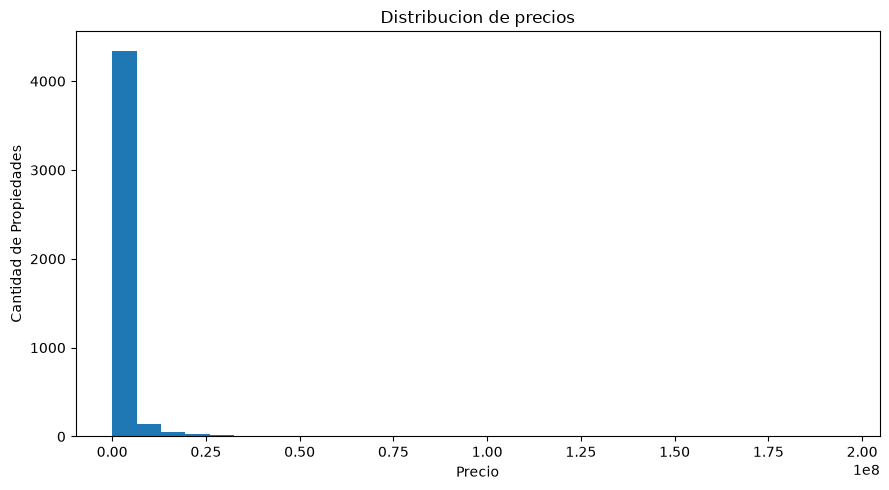

In [13]:
#Histograma de precios

plt.figure(figsize=(9,5))
plt.hist(df['PRICE'], bins=30)
plt.xlabel('Precio')
plt.ylabel('Cantidad de Propiedades')
plt.title('Distribucion de precios')

plt.tight_layout()
plt.savefig('../graficas/02_Histograma_Precios_actualizado.png')
plt.show()

In [4]:
print(df['PRICE'].describe().apply(lambda x: f'{x:,.2f}'))
print()
print(
    df.nlargest(20, 'PRICE')[
        ['PRICE', 'BEDS', 'BATH', 'TYPE']
    ]
)

print()
print("Más de $10M:", (df['PRICE'] > 10_000_000).sum())
print("Más de $50M:", (df['PRICE'] > 50_000_000).sum())
print("Más de $100M:", (df['PRICE'] > 100_000_000).sum())
print("Más de $1B:", (df['PRICE'] > 1_000_000_000).sum())

count            4,587.00
mean         2,381,171.68
std         32,068,307.75
min              2,494.00
25%            499,000.00
50%            825,000.00
75%          1,498,500.00
max      2,147,483,647.00
Name: PRICE, dtype: str

           PRICE  BEDS       BATH                        TYPE
292   2147483647     7   6.000000              House for sale
1      195000000     7  10.000000              Condo for sale
69      65000000     3   2.373861          Townhouse for sale
1044    60000000     8   8.000000              Co-op for sale
138     56000000    11  10.000000              House for sale
4       55000000     7   2.373861          Townhouse for sale
98      55000000     8   8.000000              House for sale
607     50000000     6   6.000000              Condo for sale
1406    48000000     5   2.373861              Co-op for sale
3260    45000000     5   2.373861              Co-op for sale
3432    44500000     5   6.000000              Co-op for sale
1418    40000000     5 

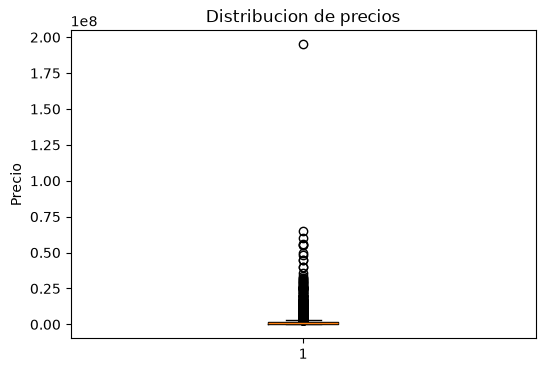

In [14]:
plt.figure(figsize=(6,4))
plt.boxplot(df['PRICE'])
plt.ylabel('Precio')
plt.title("Distribucion de precios")

plt.show()

In [5]:
Q1 = df['PRICE'].quantile(0.25)
Q3 = df['PRICE'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Limite inferior: ${limite_inferior:,.2f}")
print(f"Limite Superior: ${limite_superior:,.2f}")

Q1: $499,000.00
Q3: $1,498,500.00
IQR: $999,500.00
Limite inferior: $-1,000,250.00
Limite Superior: $2,997,750.00


In [6]:
print(df.loc[df['PRICE'] == df['PRICE'].max()].T)

                                                                     292
BROKERTITLE                            Brokered by ANNE LOPA REAL ESTATE
TYPE                                                      House for sale
PRICE                                                         2147483647
BEDS                                                                   7
BATH                                                                 6.0
PROPERTYSQFT                                                     10000.0
ADDRESS                                               6659-6675 Amboy Rd
STATE                                                 New York, NY 10309
MAIN_ADDRESS                        6659-6675 Amboy RdNew York, NY 10309
ADMINISTRATIVE_AREA_LEVEL_2                                United States
LOCALITY                                                        New York
SUBLOCALITY                                              Richmond County
STREET_NAME                                        

In [7]:
#Eliminar el registro erroneo
df = df[df['PRICE'] != 2147483647].copy()
df.reset_index(drop=True, inplace=True)

#verificar que se haya eliminado correctamente
print(df['PRICE'].describe().apply(lambda x: f'{x:,.2f}'))

count          4,586.00
mean       1,913,421.47
std        4,979,039.91
min            2,494.00
25%          499,000.00
50%          825,000.00
75%        1,497,250.00
max      195,000,000.00
Name: PRICE, dtype: str


### Que tipos de propiedades son mas comunes?

In [8]:
print(df['TYPE'].unique())

<StringArray>
[            'Condo for sale',             'House for sale',
         'Townhouse for sale',             'Co-op for sale',
 'Multi-family home for sale',                   'For sale',
                 'Contingent',              'Land for sale',
                'Foreclosure',                    'Pending',
                'Coming Soon',      'Mobile house for sale',
            'Condop for sale']
Length: 13, dtype: str


In [9]:
#Feature engineering para crear 2 nuevas columnas de Property_type y Listing_status



#1. Crear inicialmente PROPERTY_TYPE como Unknown

df['PROPERTY_TYPE'] = "Unknown"

#2. Crear mascara

mascara = (
    df['TYPE'].str.contains('for sale', case=False, na=False)
    &
    (df['TYPE'].str.lower() != 'for sale')
)        

#3. Transformar solamente las filas dela mascara
df.loc[mascara, 'PROPERTY_TYPE'] = (
    df['TYPE']
    .str.replace('for sale', '', case=False)
    .str.strip()

)

print(df['PROPERTY_TYPE'].value_counts())
print('Nueva dimension del dataset:', df.shape)

PROPERTY_TYPE
Co-op                1388
House                 965
Condo                 842
Multi-family home     699
Unknown               352
Townhouse             288
Land                   47
Condop                  4
Mobile house            1
Name: count, dtype: int64
Nueva dimension del dataset: (4586, 18)


In [11]:
#Feature engineering 2 - Listing_status



#2.Crear la mascara
mascara_status = df['TYPE'].str.contains(
    'for sale',
    case=False,
    na=False
)

df.loc[mascara_status, 'LISTING_STATUS'] = 'For Sale'
df.loc[~mascara_status, 'LISTING_STATUS'] = (df.loc[~mascara_status, 'TYPE'])

print(
    df[['TYPE', 'PROPERTY_TYPE', 'LISTING_STATUS']].value_counts()
)
print('Nueva dimension del dataset:', df.shape)



TYPE                        PROPERTY_TYPE      LISTING_STATUS
Co-op for sale              Co-op              For Sale          1388
House for sale              House              For Sale           965
Condo for sale              Condo              For Sale           842
Multi-family home for sale  Multi-family home  For Sale           699
Townhouse for sale          Townhouse          For Sale           288
Pending                     Unknown            Pending            229
Contingent                  Unknown            Contingent          87
Land for sale               Land               For Sale            47
For sale                    Unknown            For Sale            20
Foreclosure                 Unknown            Foreclosure         14
Condop for sale             Condop             For Sale             4
Coming Soon                 Unknown            Coming Soon          2
Mobile house for sale       Mobile house       For Sale             1
Name: count, dtype: int64
Nu

In [12]:
for_sale = df[df['TYPE'] == 'For sale']

print(
    for_sale[
        [
            'TYPE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'FORMATTED_ADDRESS', 'PRICE'
        ]

    ].to_string()
)

print("\nCantidad:", len(for_sale))


          TYPE  BEDS      BATH  PROPERTYSQFT                                          FORMATTED_ADDRESS    PRICE
59    For sale     3  2.000000   1952.000000                 184 Lincoln Pl #2, Brooklyn, NY 11217, USA  3150000
89    For sale     1  1.000000    621.000000                    218 W 103rd St, New York, NY 10025, USA   950000
101   For sale     2  2.000000   1400.000000                    218 W 103rd St, New York, NY 10025, USA  2280000
148   For sale     2  2.000000   1132.000000                    218 W 103rd St, New York, NY 10025, USA  1740000
184   For sale     3  1.000000    230.000000                  45 Madison St #1, New York, NY 10038, USA    65000
196   For sale     6  6.000000   6688.000000                 726 Nostrand Ave., Brooklyn, NY 11216, USA  2400000
254   For sale     8  4.000000   2184.207862                122 Willoughby Ave, Brooklyn, NY 11205, USA  2700000
267   For sale     2  2.000000   2184.207862                  995 5th Ave #11b, New York, NY 100

In [13]:
print(
    df.nsmallest(20, 'PRICE')[
        ['TYPE', 'PRICE', 'BEDS', 'PROPERTYSQFT', 'FORMATTED_ADDRESS']
    ].to_string()
)

media_sqft = df['PROPERTYSQFT'].mean()
mediana_sqft = df['PROPERTYSQFT'].median()

print()
print('Media de Square Footage de la propiedad', media_sqft)
print('Mediana de Square Footage de la propiedad', mediana_sqft)

print()
print("Registros con 2184.207862:", (df['PROPERTYSQFT'].round(6) == 2184.207862).sum())




                TYPE   PRICE  BEDS  PROPERTYSQFT                                  FORMATTED_ADDRESS
304         For sale    2494     2   2184.207862        635 W 170th St #4f, New York, NY 10032, USA
297         For sale    3225     3   2184.207862        635 W 170th St #2c, New York, NY 10032, USA
346    Land for sale    5800     3   2184.207862          4515 Avenue N #5, Brooklyn, NY 11234, USA
448   Co-op for sale   49500     3    800.000000      150 City Island Ave #3e, Bronx, NY 10464, USA
949   Condo for sale   60000     3    445.000000        2 E 55th St 809 35, New York, NY 10022, USA
184         For sale   65000     3    230.000000          45 Madison St #1, New York, NY 10038, USA
3     Condo for sale   69000     3    445.000000               2 E 55th St, New York, NY 10022, USA
243   Co-op for sale   69000     1    850.000000        1185 Anderson Ave #2e, Bronx, NY 10452, USA
129   Co-op for sale   69900     2    700.000000            61 Edgewater Park, Bronx, NY 10465, USA


In [14]:
print(df[df['PRICE'] < 10_000]
      [
          ['TYPE', 'PRICE', 'BEDS', 'PROPERTYSQFT', 'FORMATTED_ADDRESS']
      ].to_string())

              TYPE  PRICE  BEDS  PROPERTYSQFT                            FORMATTED_ADDRESS
297       For sale   3225     3   2184.207862  635 W 170th St #2c, New York, NY 10032, USA
304       For sale   2494     2   2184.207862  635 W 170th St #4f, New York, NY 10032, USA
346  Land for sale   5800     3   2184.207862    4515 Avenue N #5, Brooklyn, NY 11234, USA


In [15]:
df = df[df['PRICE'] >= 10_000].copy()
df.reset_index(drop=True, inplace=True)


### Análisis de `PRICE`
El histograma y boxplot permitieron detectar valores extremos que distorsionaban considerablemente la distribución.

- Se identificó un precio de **$2,147,483,647**, considerado un dato erróneo tras su investigación.
- También se detectaron tres registros con precios inferiores a **$10,000** ($2,494, $3,225 y $5,800) que presentaban inconsistencias con el resto de los datos.
- Estos registros anómalos fueron eliminados.
- Los demás precios elevados fueron conservados, ya que un valor estadísticamente atípico no necesariamente representa un dato incorrecto.

### Análisis de `PROPERTYSQFT`
Se encontró que el valor **2184.207862 sqft** aparece en **1,539 registros**, indicando que probablemente fue utilizado previamente para imputar superficies faltantes. Por esta razón, la ausencia de valores `NaN` no implica necesariamente que todos los valores del dataset sean datos originales.

### Feature Engineering de `TYPE`
La variable `TYPE` mezclaba información sobre el **tipo de propiedad** y el **estado del anuncio**. Para separar ambos conceptos se crearon:

- `PROPERTY_TYPE`: identifica categorías como `House`, `Condo`, `Co-op`, `Townhouse`, etc. Cuando el tipo específico no está disponible se utiliza `Unknown`.
- `LISTING_STATUS`: identifica el estado del anuncio como `For sale`, `Pending`, `Contingent`, `Foreclosure` o `Coming Soon`.

Esta transformación permite disponer de variables con un significado más claro y apropiado para las siguientes etapas de preparación y modelado.

### Existe relacion entre BEDS y PRICE?


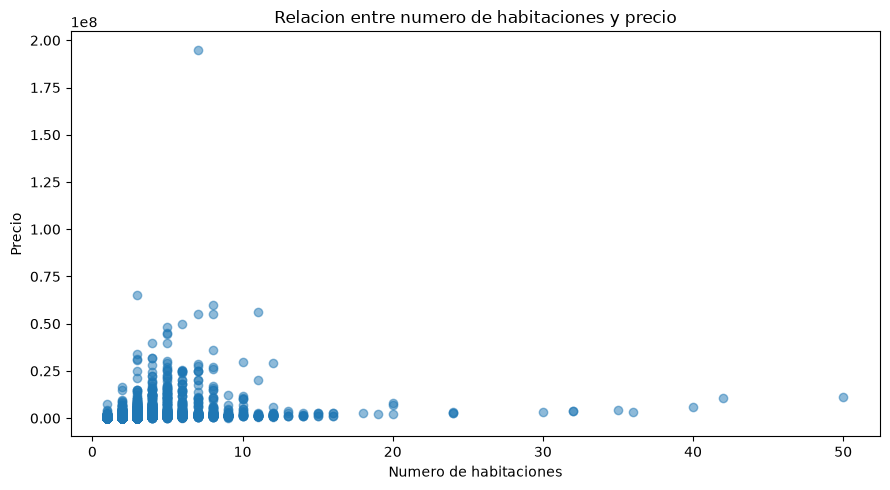

In [18]:
plt.figure(figsize=(9,5))

plt.scatter(df['BEDS'], df['PRICE'], alpha=0.5)
plt.title('Relacion entre numero de habitaciones y precio')
plt.xlabel('Numero de habitaciones')
plt.ylabel('Precio')
plt.tight_layout()
plt.savefig('../graficas/04_Relacion_Precio_habitacion')
plt.show()



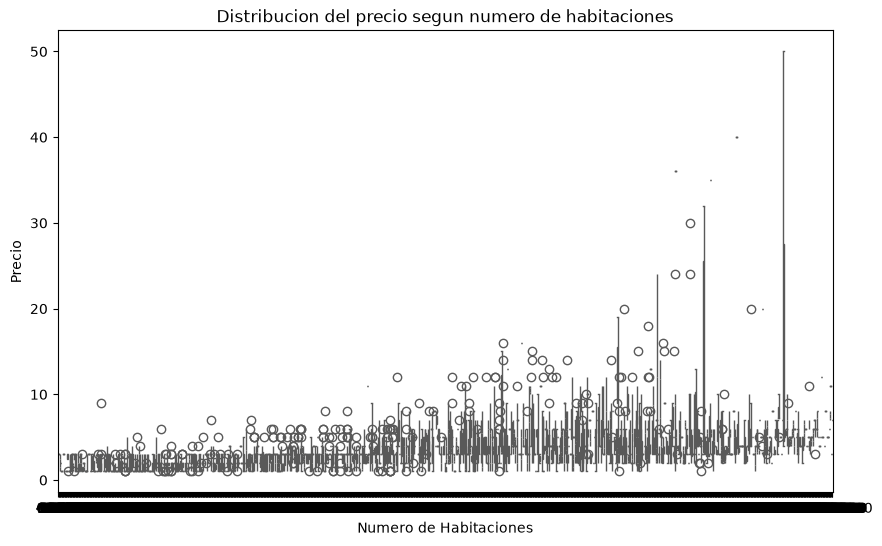

                   count      mean  median  max
PROPERTY_TYPE                                  
Multi-family home    699  6.261803     5.0   50
House                965  3.730570     3.0   32
Townhouse            288  5.020833     5.0   14
Unknown              350  3.242857     3.0   12
Condo                842  2.327791     2.0   11
Co-op               1388  1.984870     2.0    8
Mobile house           1  6.000000     6.0    6
Land                  46  3.000000     3.0    3
Condop                 4  1.750000     1.5    3


In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='PRICE', y='BEDS', hue='PRICE', palette='Set2', legend=False)
plt.title('Distribucion del precio segun numero de habitaciones')
plt.xlabel('Numero de Habitaciones')
plt.ylabel('Precio')
plt.suptitle('')

plt.show()

print(
    df.groupby('PROPERTY_TYPE')['BEDS']
      .agg(['count', 'mean', 'median', 'max'])
      .sort_values('max', ascending=False)
)

In [19]:
print('Busqueda de Propiedades tipo Condominio')
print(
    df[df['PROPERTY_TYPE'] == 'Condo'][
        ['PROPERTY_TYPE', 'BEDS', 'BATH',
         'PROPERTYSQFT', 'PRICE', 'FORMATTED_ADDRESS']
    ]
    .sort_values('BEDS', ascending=False)
    .head(15)
    .to_string()
)

print('\nBusqueda de Propiedades tipo Casas:')
print(df[df['PROPERTY_TYPE'] == 'House']
      [
          ['PROPERTY_TYPE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'PRICE', 'FORMATTED_ADDRESS']
      ].sort_values('BEDS', ascending=False)
      .head(15)
      .to_string())

Busqueda de Propiedades tipo Condominio
     PROPERTY_TYPE  BEDS       BATH  PROPERTYSQFT      PRICE                                        FORMATTED_ADDRESS
1237         Condo    11   1.000000         747.0     747000          400 Central Park W #8h, New York, NY 10025, USA
1            Condo     7  10.000000       17545.0  195000000                   217 W 57th St, New York, NY 10019, USA
1904         Condo     7   4.000000        6300.0   17500000             140 Franklin St #2b, New York, NY 10013, USA
496          Condo     7   8.000000        8139.0   27750000              551 W 21st St #15a, New York, NY 10011, USA
1726         Condo     6   7.000000        4908.0   11500000               522 W 29th St #3a, New York, NY 10001, USA
603          Condo     6   6.000000        6569.0   50000000              100 Vandam St #20a, New York, NY 10013, USA
1706         Condo     6   2.373861        8500.0   14995000          360 Furman St APT 1216, Brooklyn, NY 11201, USA
3608         Con

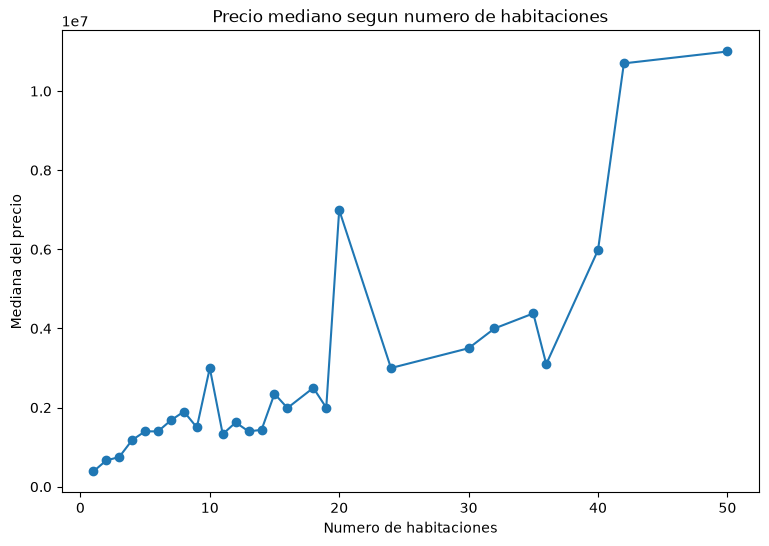

Precio mediano segun numero de habitaciones
      count      median
BEDS                   
1       779    385000.0
2       949    665000.0
3      1395    750000.0
4       544   1180000.0
5       339   1399000.0
6       260   1399497.5
7        99   1680000.0
8        81   1899000.0
9        38   1499000.0
10       21   3000000.0
11       20   1329444.0
12       22   1624000.0
13        5   1399000.0
14        6   1437500.0
15        5   2350000.0
16        4   1989500.0
18        1   2499000.0
19        1   1998000.0
20        3   6995000.0
24        3   3000000.0
30        1   3500000.0
32        2   4000000.0
35        1   4380000.0
36        1   3099000.0
40        1   5980000.0
42        1  10700000.0
50        1  11000000.0


In [25]:
#df.groupby('PROPERTY_TYPE')['BEDS'].agg(['count', 'mean', 'median', 'max'])
precio_por_camas = (
    df.groupby('BEDS')['PRICE'].median()
)

#Visualizar datos
plt.figure(figsize=(9,6))
plt.plot(
    precio_por_camas.index,
    precio_por_camas.values,
    marker='o'
)

plt.xlabel('Numero de habitaciones')
plt.ylabel('Mediana del precio')
plt.title('Precio mediano segun numero de habitaciones')
plt.show()

print('Precio mediano segun numero de habitaciones')
print(df.groupby('BEDS')['PRICE'].agg(['count', 'median']))

### Interpretacion de la Relacion de numero de habitaciones con el precio de la propiedad.

Existe una relación positiva entre el número de habitaciones (BEDS) y el precio (PRICE), especialmente entre 1 y 8 habitaciones, donde se concentra la mayor cantidad de observaciones. A partir de valores elevados de BEDS, la relación presenta mayor variabilidad debido al reducido número de propiedades disponibles y a la presencia de distintos tipos de vivienda, especialmente propiedades multifamiliares.

Columnas de la matriz de correlacion
['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']


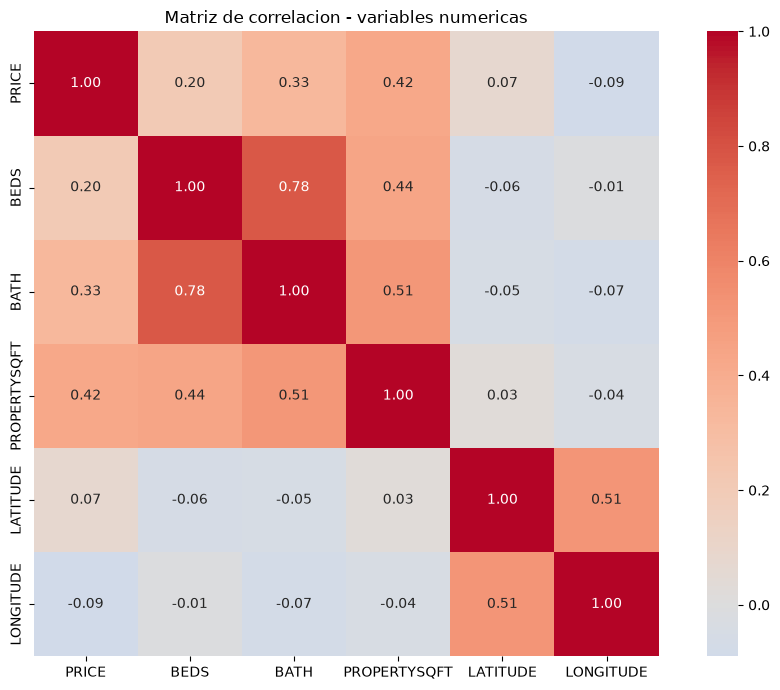


Correlacion de cada variable con Precio
PRICE           1.00
PROPERTYSQFT    0.42
BATH            0.33
BEDS            0.20
LATITUDE        0.07
LONGITUDE      -0.09
Name: PRICE, dtype: float64


In [28]:
#Matriz de Correlacion 

columnas_numericas = df.select_dtypes(['int', 'float'])

print("Columnas de la matriz de correlacion")
print(list(columnas_numericas))

correlacion = columnas_numericas.corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    correlacion,
    annot=True, #Muestra el numero de correlacion dentro de cada celda del mapa
    fmt='.2f', #define el formato de como presentaran los numeros
    cmap='coolwarm',
    center=0,
    square=True, #hace que la celda quede con forma cuadrada
    )

plt.title("Matriz de correlacion - variables numericas")
plt.tight_layout()
plt.savefig('../graficas/05_correlacion.png')
plt.show()

#prints para reforzar la grafica
print('\nCorrelacion de cada variable con Precio')
print(correlacion['PRICE'].sort_values(ascending=False).round(2))

In [29]:
df.to_csv('../datasets/NY_House_Dataset_clean.csv')